<a href="https://colab.research.google.com/github/peakodev/data_science/blob/main/home06/Hw6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Завдання

У цьому завданні вам потрібно завантажити ось цей датасет. Тут ви знайдете 2 файли - з двовимірним датасетом та датасетом mnist. Для кожного з них застосуйте алгоритм K-means для кластеризації. Щоб знайти оптимальну кількість кластерів, скористайтесь ліктевим методом.

Візуалізуйте результат роботи кластеризації. Для випадку з mnist датасетом, вам потрібно ще скористатись алгоритмом PCA щоб зменшити розмірність вашим даних до 2-вимірного варіанту.

In [56]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import seaborn as sns
sns.set_style("darkgrid")

from warnings import simplefilter
simplefilter(action="ignore", category=FutureWarning)

# 2d dataset

In [2]:
df_2d = pd.read_csv('data_2d.csv')

In [3]:
df_2d.shape

(199, 3)

In [4]:
df_2d.head()

,0.000000000000000000e+00,-7.687164597386728637e-01,4.608603078297135447e-01
0,0.0,2.687848,2.366961
1,0.0,-0.201379,0.470430
2,0.0,0.608496,1.225400
3,0.0,-0.082282,1.137218
4,0.0,2.083069,2.694482


In [5]:
df_2d.iloc[:, 0].unique()

array([0., 1.])

In [6]:
X_2d = df_2d.iloc[:, [1, 2]]
y_2d = df_2d.iloc[:, 0]

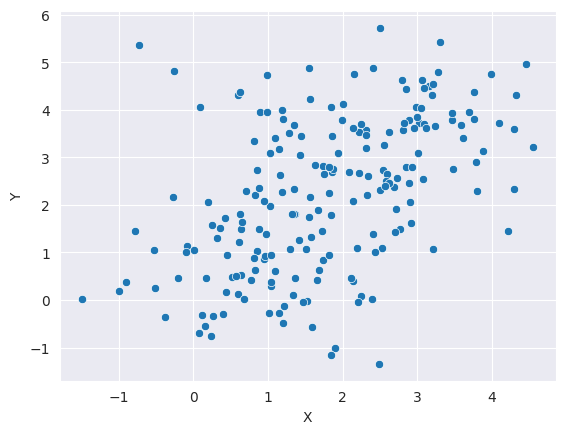

In [53]:
sns.scatterplot(x=X_2d.iloc[:, 0], y=X_2d.iloc[:, 1])
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

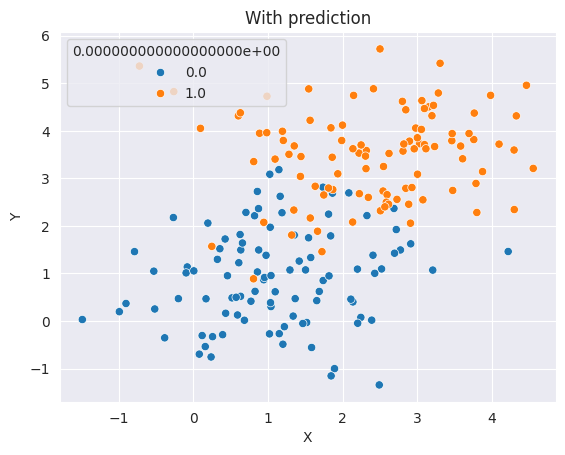

In [52]:
sns.scatterplot(x=X_2d.iloc[:, 0], y=X_2d.iloc[:, 1], hue=y_2d)
plt.title("With prediction")
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

In [25]:
elbow_range = range(1, 11)
distortions = []
for k in elbow_range:
    km = KMeans(n_clusters=k, random_state=170)
    km.fit(X_2d)
    distortions.append(km.inertia_)

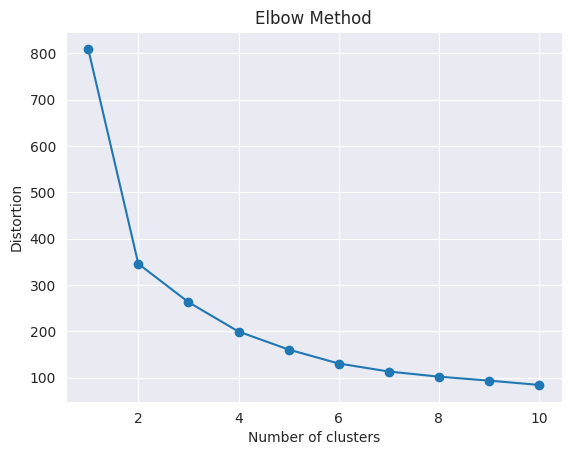

In [26]:
plt.plot(elbow_range, distortions, marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Distortion")
plt.title("Elbow Method")
plt.show()

In [45]:
cluster_count = 2

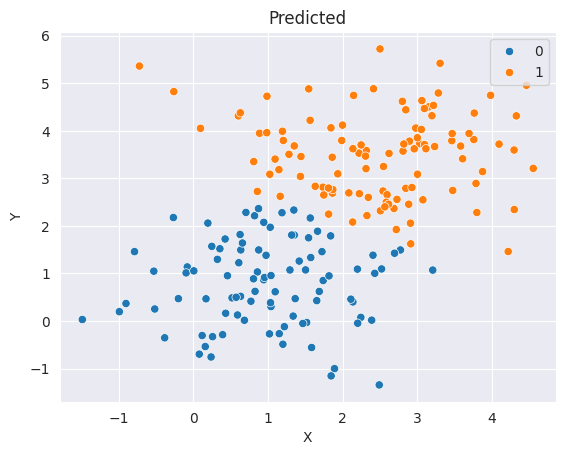

In [46]:
k_means_2d = KMeans(n_clusters=cluster_count, random_state=170)
k_means_2d.fit(X_2d)

y_2d_pred = k_means_2d.predict(X_2d)
sns.scatterplot(x=X_2d.iloc[:, 0], y=X_2d.iloc[:, 1], hue=y_2d_pred)
plt.title("Predicted")
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


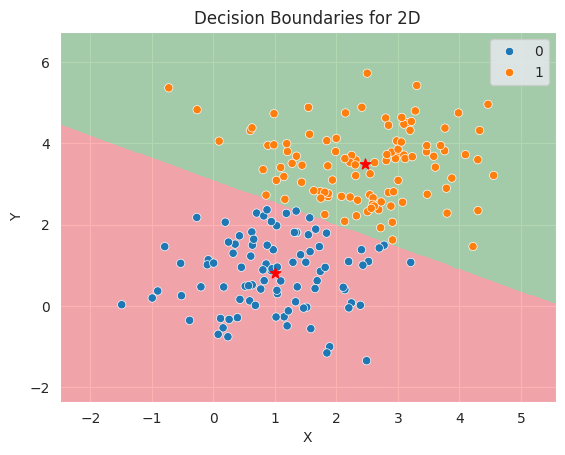

In [48]:
# create a meshgrid to plot the decision boundaries
xx, yy = np.meshgrid(
    np.linspace(X_2d.iloc[:, 0].min() - 1, X_2d.iloc[:, 0].max() + 1, 500),
    np.linspace(X_2d.iloc[:, 1].min() - 1, X_2d.iloc[:, 1].max() + 1, 500)
)

# predict the clusters for each point in the meshgrid
grid_pred = k_means_2d.predict(np.c_[xx.ravel(), yy.ravel()])
grid_pred = grid_pred.reshape(xx.shape)

# plot the decision boundaries
plt.pcolormesh(xx, yy, grid_pred, cmap=ListedColormap(["r", "g"]), alpha=0.3)

# plot the training points
sns.scatterplot(x=X_2d.iloc[:, 0], y=X_2d.iloc[:, 1], hue=y_2d_pred)

# plot the centroids
centroids_x = k_means_2d.cluster_centers_[:, 0]
centroids_y = k_means_2d.cluster_centers_[:, 1]

plt.scatter(centroids_x, centroids_y, marker="*", s=60, color="red")

plt.title("Decision Boundaries for 2D")
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

# mnist

In [49]:
df_mnist = pd.read_csv('mnist.csv')

In [50]:
df_mnist.shape

(499, 785)

In [51]:
df_mnist.head()

,7,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.658,0.659,0.660,0.661,0.662,0.663,0.664,0.665,0.666,0.667
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [54]:
df_mnist.iloc[:, 0].unique()

array([2, 1, 0, 4, 9, 5, 6, 7, 3, 8])

In [67]:
target_mnist = df_mnist.iloc[:, 0]
X_mnist = df_mnist.iloc[:, 1:]
X_mnist.head()

,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,...,0.658,0.659,0.660,0.661,0.662,0.663,0.664,0.665,0.666,0.667
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [68]:
X_mnist.shape

(499, 784)

In [69]:
# 1. Стандартизація даних
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_mnist)

# 2. Створення об'єкта PCA та зменшення розмірності до 2 компонент
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

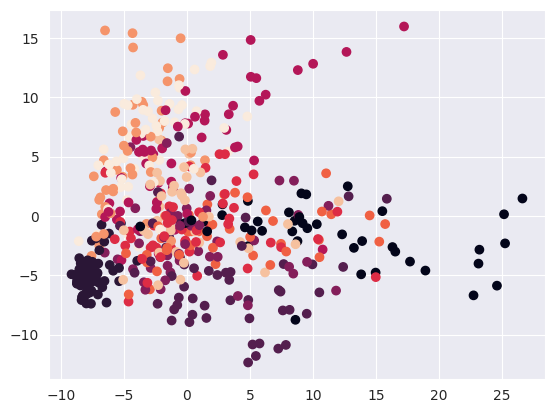

In [72]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=target_mnist)
plt.show()

In [71]:
pca.explained_variance_ratio_.sum()
explained_variance = pca.explained_variance_ratio_
compression_loss = 1 - explained_variance.sum()

print("Втрата стиснення:", compression_loss)

Втрата стиснення: 0.8763577857801713


In [81]:
elbow_range_mnist = range(1, 15)
distortions_mnist = []
for k in elbow_range_mnist:
    km_mnist = KMeans(n_clusters=k, random_state=170)
    km_mnist.fit(X_pca)
    distortions_mnist.append(km_mnist.inertia_)

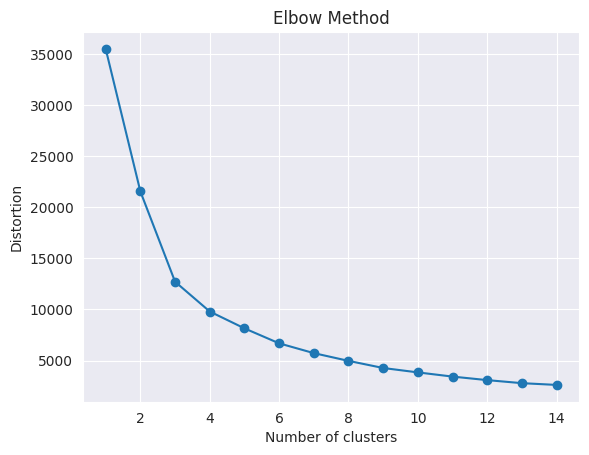

In [82]:
plt.plot(elbow_range_mnist, distortions_mnist, marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Distortion")
plt.title("Elbow Method")
plt.show()

In [83]:
cluster_count_mnist = 4

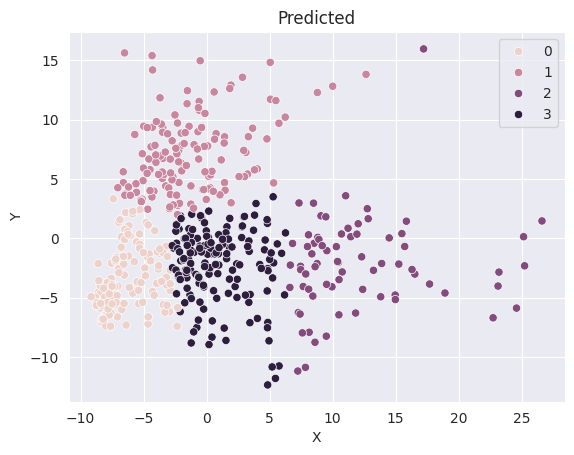

In [85]:
k_means_mnist = KMeans(n_clusters=cluster_count_mnist, random_state=170)
k_means_mnist.fit(X_pca)

y_pca_pred = k_means_mnist.predict(X_pca)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_pca_pred)
plt.title("Predicted")
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

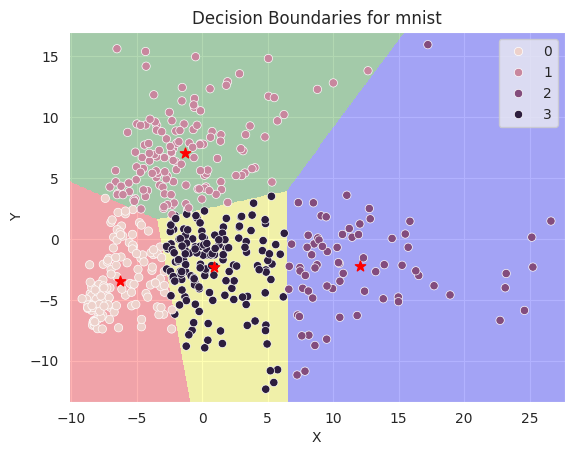

In [86]:
# create a meshgrid to plot the decision boundaries
xx_mnist, yy_mnist = np.meshgrid(
    np.linspace(X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1, 500),
    np.linspace(X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1, 500)
)

# predict the clusters for each point in the meshgrid
grid_pred_mnist = k_means_mnist.predict(np.c_[xx_mnist.ravel(), yy_mnist.ravel()])
grid_pred_mnist = grid_pred_mnist.reshape(xx_mnist.shape)

# plot the decision boundaries
plt.pcolormesh(xx_mnist, yy_mnist, grid_pred_mnist, cmap=ListedColormap(["red", "green", "blue", "yellow"]), alpha=0.3)

# plot the training points
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_pca_pred)

# plot the centroids
mnist_centroids_x = k_means_mnist.cluster_centers_[:, 0]
mnist_centroids_y = k_means_mnist.cluster_centers_[:, 1]

plt.scatter(mnist_centroids_x, mnist_centroids_y, marker="*", s=60, color="red")

plt.title("Decision Boundaries for mnist")
plt.xlabel('X')
plt.ylabel('Y')
plt.show()